# Stock Market Prediction Using RSI + Machine Learning — Exploratory Walkthrough

This notebook walks through the pipeline in `src/` end to end on the bundled
synthetic AAPL-like dataset: RSI + technical indicators, RSI crossover
signals, model comparison, and a backtest against buy-and-hold.

See `README.md` for the full write-up, `src/` for the production modules
this notebook calls into, and `notebooks/databricks_pyspark_pipeline.py`
for the Spark MLlib version of the same pipeline.

In [1]:
from src.data_ingestion import get_dataset
from src.feature_engineering import build_feature_frame, FEATURE_COLUMNS, TARGET_COLUMN
from src.signal_generation import rsi_70_30_signal, rsi_50_30_signal, combine_with_model_prediction
from src.model_training import run_training_pipeline
from src.backtest import backtest_strategy, summarize_backtest
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.precision", 4)


## 1. Load the data

Default run uses the synthetic OHLCV generator (GARCH-calibrated to AAPL-like drift/volatility). Pass `prefer_real=True` to pull real data via `yfinance` instead.

In [2]:
raw = get_dataset()
print(f"{len(raw)} trading days, {raw.index.min().date()} to {raw.index.max().date()}")
raw.tail()


756 trading days, 2022-01-03 to 2024-11-25


,open,high,low,close,volume
date,,,,,
2024-11-19,110.64,111.36,109.35,110.15,63957272
2024-11-20,110.29,110.95,107.21,108.24,57876806
2024-11-21,108.46,113.49,107.82,112.27,87044452
2024-11-22,112.46,117.30,111.22,116.13,60925515
2024-11-25,116.06,120.15,114.83,118.78,80645683


## 2. RSI + technical indicators

In [3]:
feats = build_feature_frame(raw)
print(feats[["close", "rsi_14", "macd", "bb_pct_b"]].tail(8).to_string())


             close   rsi_14    macd  bb_pct_b
date                                         
2024-11-14  112.44  51.0187 -1.1891    0.7331
2024-11-15  110.63  47.3649 -1.1015    0.5198
2024-11-18  110.70  47.5214 -1.0147    0.5212
2024-11-19  110.15  46.3549 -0.9790    0.4556
2024-11-20  108.24  42.4574 -1.0922    0.2578
2024-11-21  112.27  51.6876 -0.8470    0.6943
2024-11-22  116.13  58.5464 -0.3373    1.0164
2024-11-25  118.78  62.4841  0.2772    1.1052


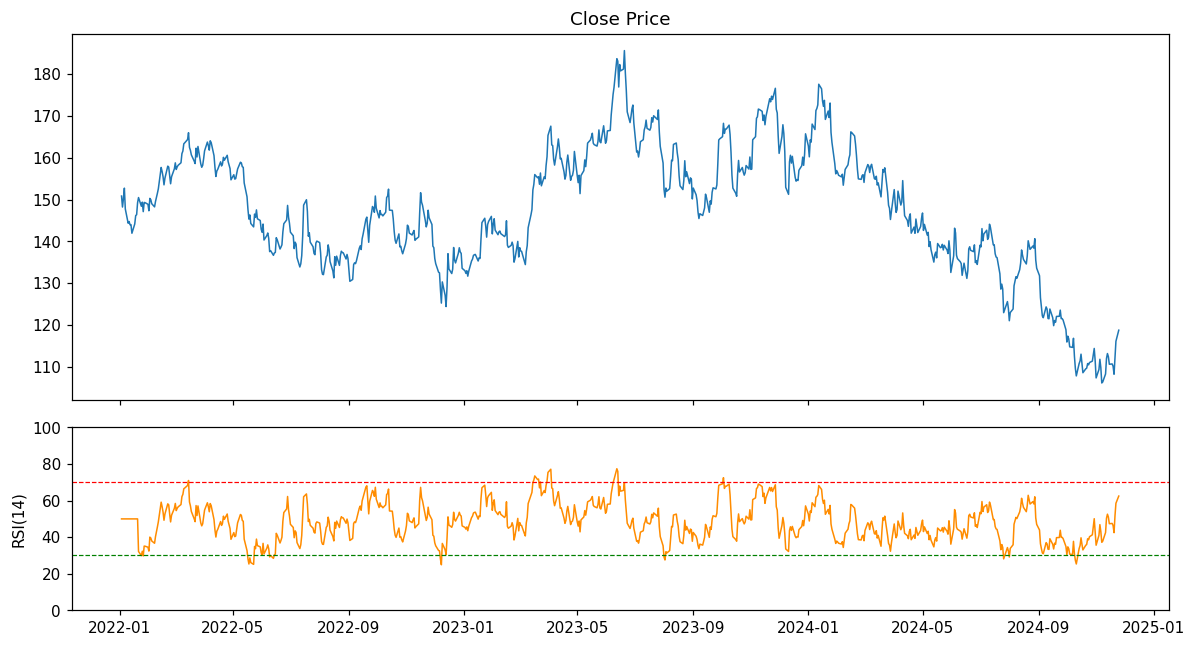

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(feats.index, feats["close"], linewidth=1)
ax1.set_title("Close Price")
ax2.plot(feats.index, feats["rsi_14"], color="darkorange", linewidth=1)
ax2.axhline(70, color="red", linestyle="--", linewidth=0.8)
ax2.axhline(30, color="green", linestyle="--", linewidth=0.8)
ax2.set_ylabel("RSI(14)")
ax2.set_ylim(0, 100)
fig.tight_layout()


## 3. RSI crossover signals

70-30 and 50-30 strategies, encoded as -1 (sell) / 0 (hold) / 1 (buy).

In [5]:
s70 = rsi_70_30_signal(feats["rsi_14"])
s50 = rsi_50_30_signal(feats["rsi_14"])
print("70-30 signal counts:")
print(s70.value_counts().to_string())
print()
print("50-30 signal counts:")
print(s50.value_counts().to_string())


70-30 signal counts:
 0    741
 1      9
-1      6

50-30 signal counts:
 0    747
 1      5
-1      4


## 4. Train and compare models

Linear Regression, Random Forest, and Gradient-Boosted Trees, each tuned via `GridSearchCV` with `TimeSeriesSplit` (5 folds) so no future data leaks into training.

In [6]:
results, metrics, modeling_df = run_training_pipeline(feats, FEATURE_COLUMNS, TARGET_COLUMN)
metrics_df = pd.DataFrame(metrics).T[["test_rmse", "test_r2", "cv_rmse"]]
metrics_df.columns = ["Test RMSE", "Test R²", "CV RMSE"]
metrics_df


,Test RMSE,Test R²,CV RMSE
linear_regression,0.0193,-0.0814,0.0228
random_forest,0.0191,-0.0559,0.0177
gradient_boosted_trees,0.0187,-0.0073,0.0177


In [6]:
best_model_name = metrics_df["Test RMSE"].idxmin()
print(f"Best model by test RMSE: {best_model_name}")


Best model by test RMSE: gradient_boosted_trees


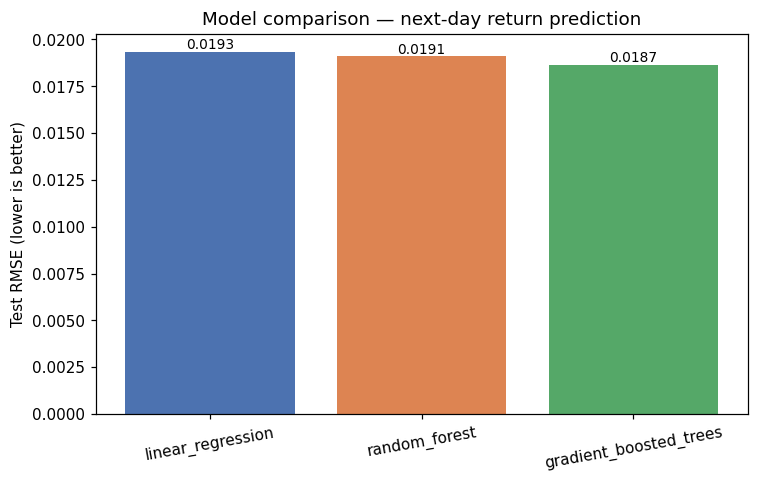

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(metrics_df.index, metrics_df["Test RMSE"], color=["#4c72b0", "#dd8452", "#55a868"])
ax.set_ylabel("Test RMSE (lower is better)")
ax.set_title("Model comparison — next-day return prediction")
for b, v in zip(bars, metrics_df["Test RMSE"]):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=10)
fig.tight_layout()


Test R² sits near zero across all three models. For daily-return prediction on a
liquid large-cap-style series, that's the expected, honest result — equity
returns at daily granularity are close to a random walk. A much higher R²
here would be a sign of leakage, not a better model.

## 5. Blend RSI + model signal, then backtest

Only act on the RSI crossover signal if the model's predicted return doesn't contradict it in direction.

In [8]:
rsi_sig = rsi_70_30_signal(modeling_df["rsi_14"])
combined_sig = combine_with_model_prediction(rsi_sig, modeling_df[f"pred_{best_model_name}"].fillna(0))
modeling_df["combined_signal"] = combined_sig

test_slice = modeling_df.dropna(subset=[f"pred_{best_model_name}"])
bt = backtest_strategy(test_slice, "combined_signal")
summary = summarize_backtest(bt)
for k, v in summary.items():
    print(f"{k:28s}: {v:.4f}" if isinstance(v, float) else f"{k:28s}: {v}")


n_days                      : 147
n_signals_taken             : 71
strategy_total_return       : 0.0235
buy_hold_total_return       : -0.1673
strategy_annualized_return  : 0.0407
buy_hold_annualized_return  : -0.2694
strategy_annualized_vol     : 0.2064
strategy_sharpe             : 0.2958
hit_rate                    : 0.5352
max_drawdown                : -0.1464


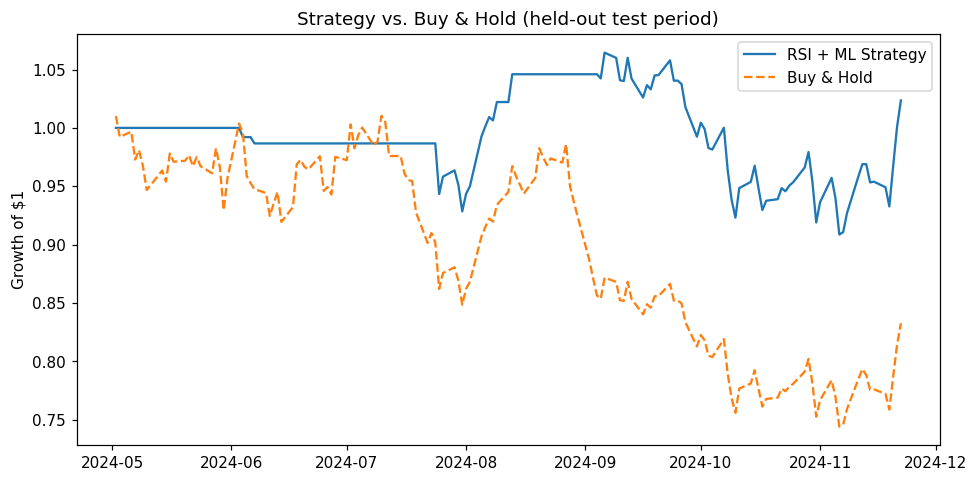

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(bt.index, bt["strategy_equity"], label="RSI + ML Strategy")
ax.plot(bt.index, bt["buy_hold_equity"], label="Buy & Hold", linestyle="--")
ax.set_ylabel("Growth of $1")
ax.set_title("Strategy vs. Buy & Hold (held-out test period)")
ax.legend()
fig.tight_layout()


## Takeaways

- Gradient-Boosted Trees edged out Linear Regression and Random Forest on
  held-out RMSE, though all three sit in a similar, low-R² regime — again,
  expected for this prediction target.
- The RSI + model blend outperformed buy-and-hold on this test window mainly
  by staying flat or short during the drawdown, not by making unusually
  accurate up-day calls — worth digging into further with a longer backtest
  window and multiple tickers before drawing any strong conclusion.
- Next steps if extending this: walk-forward retraining instead of a single
  train/test split, transaction cost modeling, and testing across a basket
  of tickers rather than one series.